# (27) contrast latency fig, find optimal params

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

Find the best ```s_freq``` and ```theta``` to use for that one neuron (```i = order[338]```)

Using: (16, 24.0)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.tuning import drifting_grating_feeder, drifting_grating_feeder_params
from utils.animation import show_movie


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Basic setup

In [3]:
pal_models = get_palette_models()

chkpts_dir = add_home('Dropbox/chkpts/_IterativeVAE')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03')
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(chkpts_dir)), len(os.listdir(figs_dir))

(420, 2)

In [4]:
files = [f for f in os.listdir(chkpts_dir) if 'vH16' in f]
files = sorted(files, key=alphanum_sort_key)

In [5]:
seq_len, beta = 16, 24

selected_fits = [
    f for f in files if (
        f't-{seq_len}_b-{beta:0.3g}' in f
        and 'softplus' not in f)
]
print(selected_fits)

[
    'gaussian+relu-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:45)',
    'gaussian-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:09)',
    'poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38)'
]

## Load trainer

In [6]:
f = next(f for f in selected_fits if 'poisson' in f)
tr = load_model_lite(pjoin(chkpts_dir, f), device=device)[0]
u0 = tonp(tr.model.layer.u_init[0].squeeze())
order = np.argsort(u0)

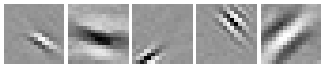

In [7]:
selected_neurons = [380, 47, 281, 117, 338]
tr.model.show(order=order[selected_neurons], method='abs-max', nrows=1, dpi=40);

## Find optimal params

```s_feq / theta```

In [8]:
param_grid = drifting_grating_feeder_params(
    contrast_min=1.0,
    contrast_max=1.0,
    s_freq_min=0.1,
    s_freq_max=3.6,
    s_freq_delta=0.1,
    theta_delta=3,
)

n_frames_for_full_cycle = 500

feeder, feeder_kws = drifting_grating_feeder(
    npix=tr.model.cfg.input_sz[-1],
    param_grid=param_grid,
    device=device,
    n_frames_per_cycle=n_frames_for_full_cycle,
)

In [9]:
len(param_grid)

2196

### fwd: xtract ftrs

In [10]:
%%time


trial_timepoints = range(
    n_frames_for_full_cycle,
    n_frames_for_full_cycle * 2,
)
n_trials = 100

spk_counts_all = []
for i in tqdm(range(n_trials)):
    tr.model.cfg.set_seeds(i)

    output = tr.model.xtract_ftr(
        feeder=FEEDER_CLASSES['drifting-grating'](**feeder_kws),
        seq=range(2 * n_frames_for_full_cycle),
        return_extras=['samples'],
    ).stack()

    spks = output['samples'][:, trial_timepoints]
    spk_counts_all.append(tonp(spks.sum(1)))

spk_counts_all = np.stack(spk_counts_all)
spk_counts_all.shape

100%|█████████████████████████████████████████| 100/100 [05:07<00:00,  3.07s/it]


CPU times: user 4min 14s, sys: 2.6 s, total: 4min 16s
Wall time: 5min 7s


(100, 2196, 512)

In [11]:
shape = (n_trials, *param_grid.param_lengths, tr.model.cfg.n_latents[0])

avg_spk_counts = spk_counts_all.reshape(shape)
avg_spk_counts = avg_spk_counts.mean(0)
avg_spk_counts.shape

(1, 36, 61, 512)

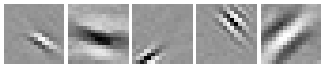

In [12]:
tr.model.show(order=order[selected_neurons], method='abs-max', nrows=1, dpi=40);

In [13]:
neuron_i = order[selected_neurons[-1]]
tuning = avg_spk_counts[..., neuron_i]

x2p = tuning[0, ...]
x2p /= np.sum(x2p)

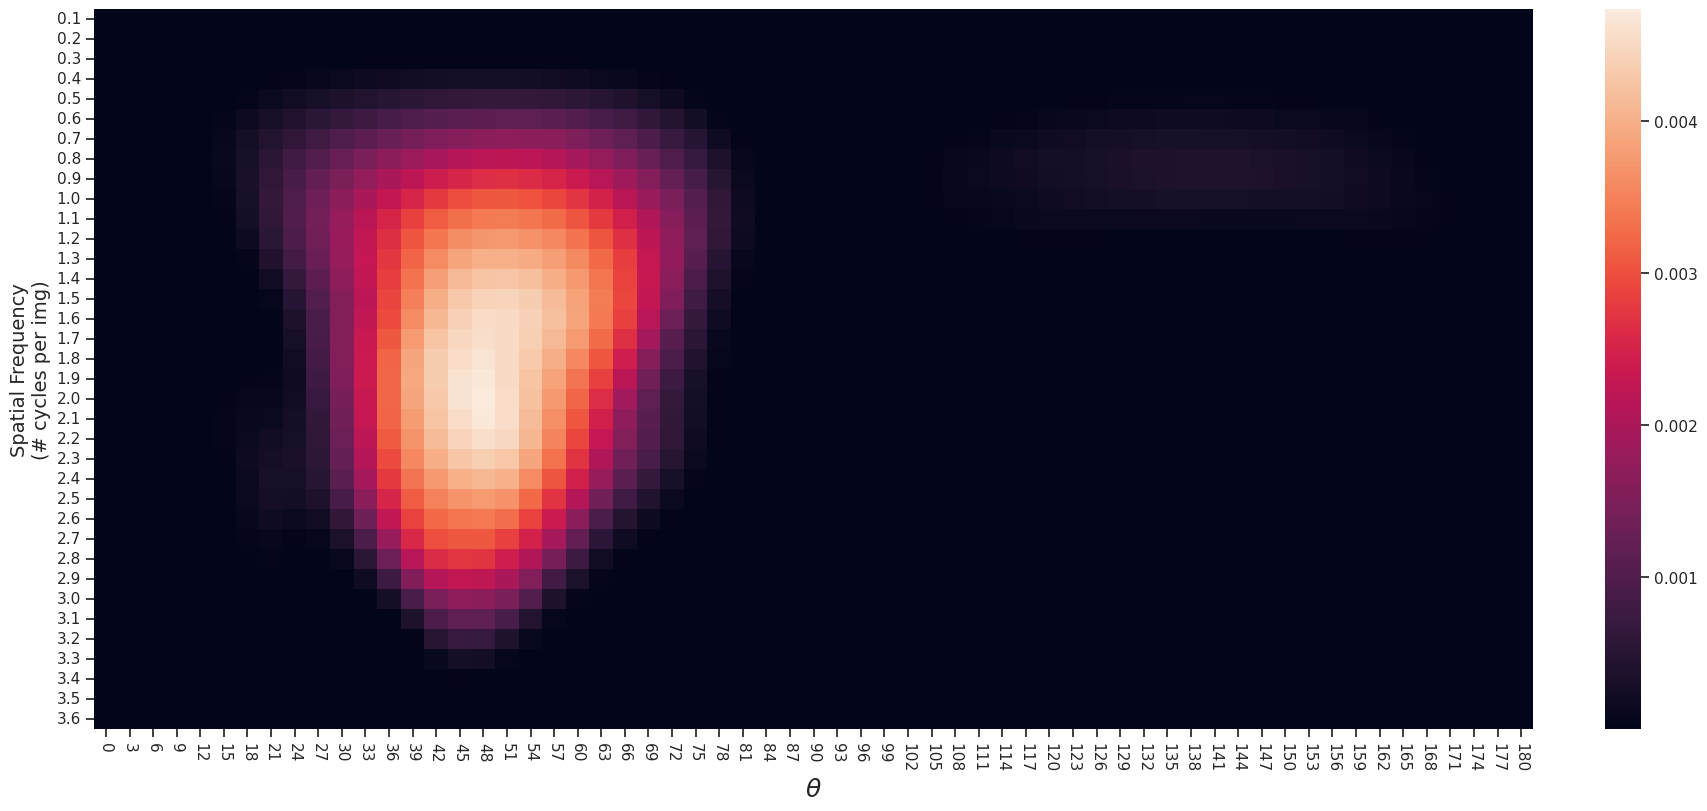

In [17]:
fig, ax = create_figure(1, 1, (17, 8))

sns.heatmap(data=x2p, ax=ax)

ax.set_ylabel('Spatial Frequency\n(# cycles per img)', fontsize=14)
ax.set_xlabel(r'$\theta$', fontsize=18)

s_freq = param_grid.param_dict['s_freq']
ax.set_yticks(np.array(range(len(s_freq))) + 0.5)
ax.set_yticklabels(s_freq, rotation=0)

theta = param_grid.param_dict['theta']
ax.set_xticks(np.array(range(len(theta))) + 0.5)
ax.set_xticklabels([str(int(angle)) for angle in theta], rotation=-90)

plt.show()

In [19]:
favorite_idx = np.argmax(tuning)
favorite_params = param_grid[favorite_idx]

print(favorite_params)

{'contrast': 1.0, 's_freq': 2.0, 'theta': 48.0}

In [20]:
favorite_s_freq_idx = param_grid.param_dict['s_freq'] == favorite_params['s_freq']
favorite_s_freq_idx = np.where(favorite_s_freq_idx)[0].item()

favorite_s_freq_idx

19

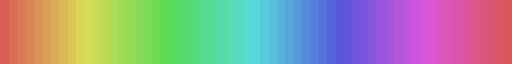

In [21]:
periodic_cmap, base_colors = get_periodic_palette(
    len(param_grid.param_dict['theta']))

periodic_cmap

In [22]:
tuning_curve_theta = tuning[0, favorite_s_freq_idx]
color = base_colors[np.argmax(tuning_curve_theta)]

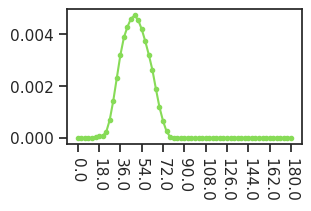

In [23]:
fig, ax = create_figure()
ax.plot(tuning_curve_theta, color=color, marker='.')

xticks, xticklabels = zip(*[
    (i, v) for i, v in
    enumerate(param_grid.param_dict['theta'])
    if i % 6 == 0
])
ax.set(xticks=xticks, xticklabels=xticklabels)
ax.tick_params(axis='x', labelrotation=-90)
plt.show()